# Flagging Potentially Hazardous Asteroids
### Milestone 2 - Initial EDA
Faaiz Abdullah - 301472058
IAT 461 Summer 2026

The client proposal (written by Cohen ter Heide) is for AstroCour, a planetary defense group modeled after real organizations like NASA's Planetary Defense Coordination Office.

The question is a yes/no one: given an asteroid's size, speed, and how close its orbit brings it to Earth, is it "potentially hazardous" or not. Since every asteroid in the dataset already has this label attached (NASA's own hazardous/not-hazardous classification), this is a supervised classification problem, not something exploratory.

This notebook covers the EDA for Checkpoint 1.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (9, 5)

df = pd.read_csv('nasa.csv')
df.shape

(4687, 40)

## Data Loading

Source: NASA's Near-Earth Object dataset, originally pulled from NASA's NeoWs API. Cohen linked a CSV mirror on GitHub in the proposal, I downloaded it directly from there. 4687 rows, one per asteroid, 40 columns.

Column dictionary for the ones I'll actually be using (a lot of the 40 columns are just unit conversions of each other, e.g. diameter in km vs miles vs feet, so I'm not listing every single one):

- **Absolute Magnitude** - how bright/big the asteroid is, lower number means bigger object
- **Est Dia in KM (min/max)** - estimated diameter range in kilometers
- **Relative Velocity km per sec** - how fast it's moving relative to Earth
- **Miss Dist. (kilometers)** - how close its path comes to Earth
- **Eccentricity** - how stretched out the orbit is, 0 is a perfect circle
- **Inclination** - how tilted the orbit is compared to Earth's orbital plane
- **Orbital Period** - days to complete one orbit around the sun
- **Hazardous** - the target column, True/False

There's also stuff like Orbit ID, Orbit Determination Date, and Equinox that are basically bookkeeping fields from NASA's tracking system rather than physical properties, so I don't expect those to be useful for prediction.

In [2]:
df.head()

,Neo Reference ID,Name,Absolute Magnitude,Est Dia in KM(min),Est Dia in KM(max),Est Dia in M(min),Est Dia in M(max),Est Dia in Miles(min),Est Dia in Miles(max),Est Dia in Feet(min),...,Asc Node Longitude,Orbital Period,Perihelion Distance,Perihelion Arg,Aphelion Dist,Perihelion Time,Mean Anomaly,Mean Motion,Equinox,Hazardous
0,3703080,3703080,21.6,0.127220,0.284472,127.219879,284.472297,0.079051,0.176763,417.388066,...,314.373913,609.599786,0.808259,57.257470,2.005764,2.458162e+06,264.837533,0.590551,J2000,True
1,3723955,3723955,21.3,0.146068,0.326618,146.067964,326.617897,0.090762,0.202951,479.225620,...,136.717242,425.869294,0.718200,313.091975,1.497352,2.457795e+06,173.741112,0.845330,J2000,False
2,2446862,2446862,20.3,0.231502,0.517654,231.502122,517.654482,0.143849,0.321655,759.521423,...,259.475979,643.580228,0.950791,248.415038,1.966857,2.458120e+06,292.893654,0.559371,J2000,True
3,3092506,3092506,27.4,0.008801,0.019681,8.801465,19.680675,0.005469,0.012229,28.876199,...,57.173266,514.082140,0.983902,18.707701,1.527904,2.457902e+06,68.741007,0.700277,J2000,False
4,3514799,3514799,21.6,0.127220,0.284472,127.219879,284.472297,0.079051,0.176763,417.388066,...,84.629307,495.597821,0.967687,158.263596,1.483543,2.457814e+06,135.142133,0.726395,J2000,True


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4687 entries, 0 to 4686
Data columns (total 40 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Neo Reference ID              4687 non-null   int64  
 1   Name                          4687 non-null   int64  
 2   Absolute Magnitude            4687 non-null   float64
 3   Est Dia in KM(min)            4687 non-null   float64
 4   Est Dia in KM(max)            4687 non-null   float64
 5   Est Dia in M(min)             4687 non-null   float64
 6   Est Dia in M(max)             4687 non-null   float64
 7   Est Dia in Miles(min)         4687 non-null   float64
 8   Est Dia in Miles(max)         4687 non-null   float64
 9   Est Dia in Feet(min)          4687 non-null   float64
 10  Est Dia in Feet(max)          4687 non-null   float64
 11  Close Approach Date           4687 non-null   object 
 12  Epoch Date Close Approach     4687 non-null   int64  
 13  Rel

In [4]:
df.isnull().sum().sum()

np.int64(0)

## Class Balance

This is the big one going into modeling. If the classes are lopsided, plain accuracy would be a bad metric and I'd need to think about things like class weighting or resampling before Checkpoint 2.

Hazardous
False    3932
True      755
Name: count, dtype: int64
Hazardous
False    83.9
True     16.1
Name: proportion, dtype: float64


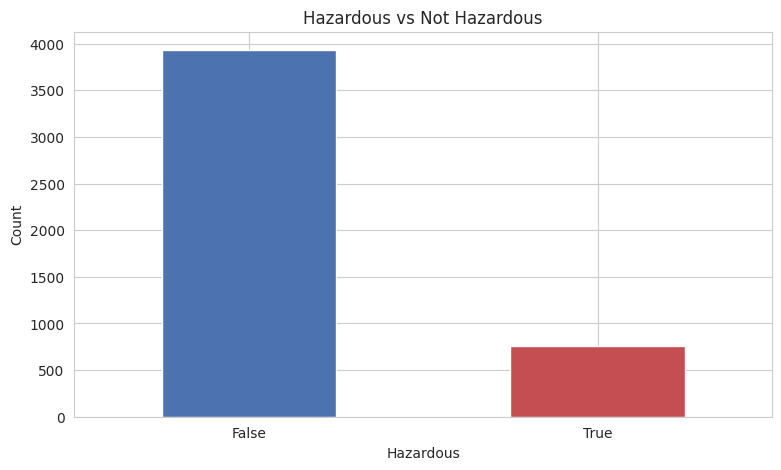

In [5]:
counts = df['Hazardous'].value_counts()
pct = df['Hazardous'].value_counts(normalize=True) * 100
print(counts)
print(pct.round(1))

ax = counts.plot(kind='bar', color=['#4C72B0', '#C44E52'])
ax.set_title('Hazardous vs Not Hazardous')
ax.set_xlabel('Hazardous')
ax.set_ylabel('Count')
plt.xticks(rotation=0)
plt.show()

About 16% of asteroids in this set are labeled hazardous, so roughly 1 in 6. That lines up with what Cohen flagged as a constraint in the proposal. This confirms accuracy alone won't tell me much once I get to modeling, since a model that just predicts "not hazardous" every time would already be right 84% of the time and be completely useless. Precision, recall, and probably ROC-AUC are going to matter a lot more here.

In [6]:
print(df['Orbiting Body'].unique())
print(df['Equinox'].unique())

['Earth']
['J2000']


Both are constant across every row (Orbiting Body is always Earth, Equinox is always J2000), so they carry zero information and I'll drop them before modeling. Same logic probably applies to some of the ID/date bookkeeping columns, I'll deal with the full column trim when I actually build features in Checkpoint 2.

## Feature Distributions

Looking at the core physical features Cohen called out in the proposal: size, speed, and orbital closeness.

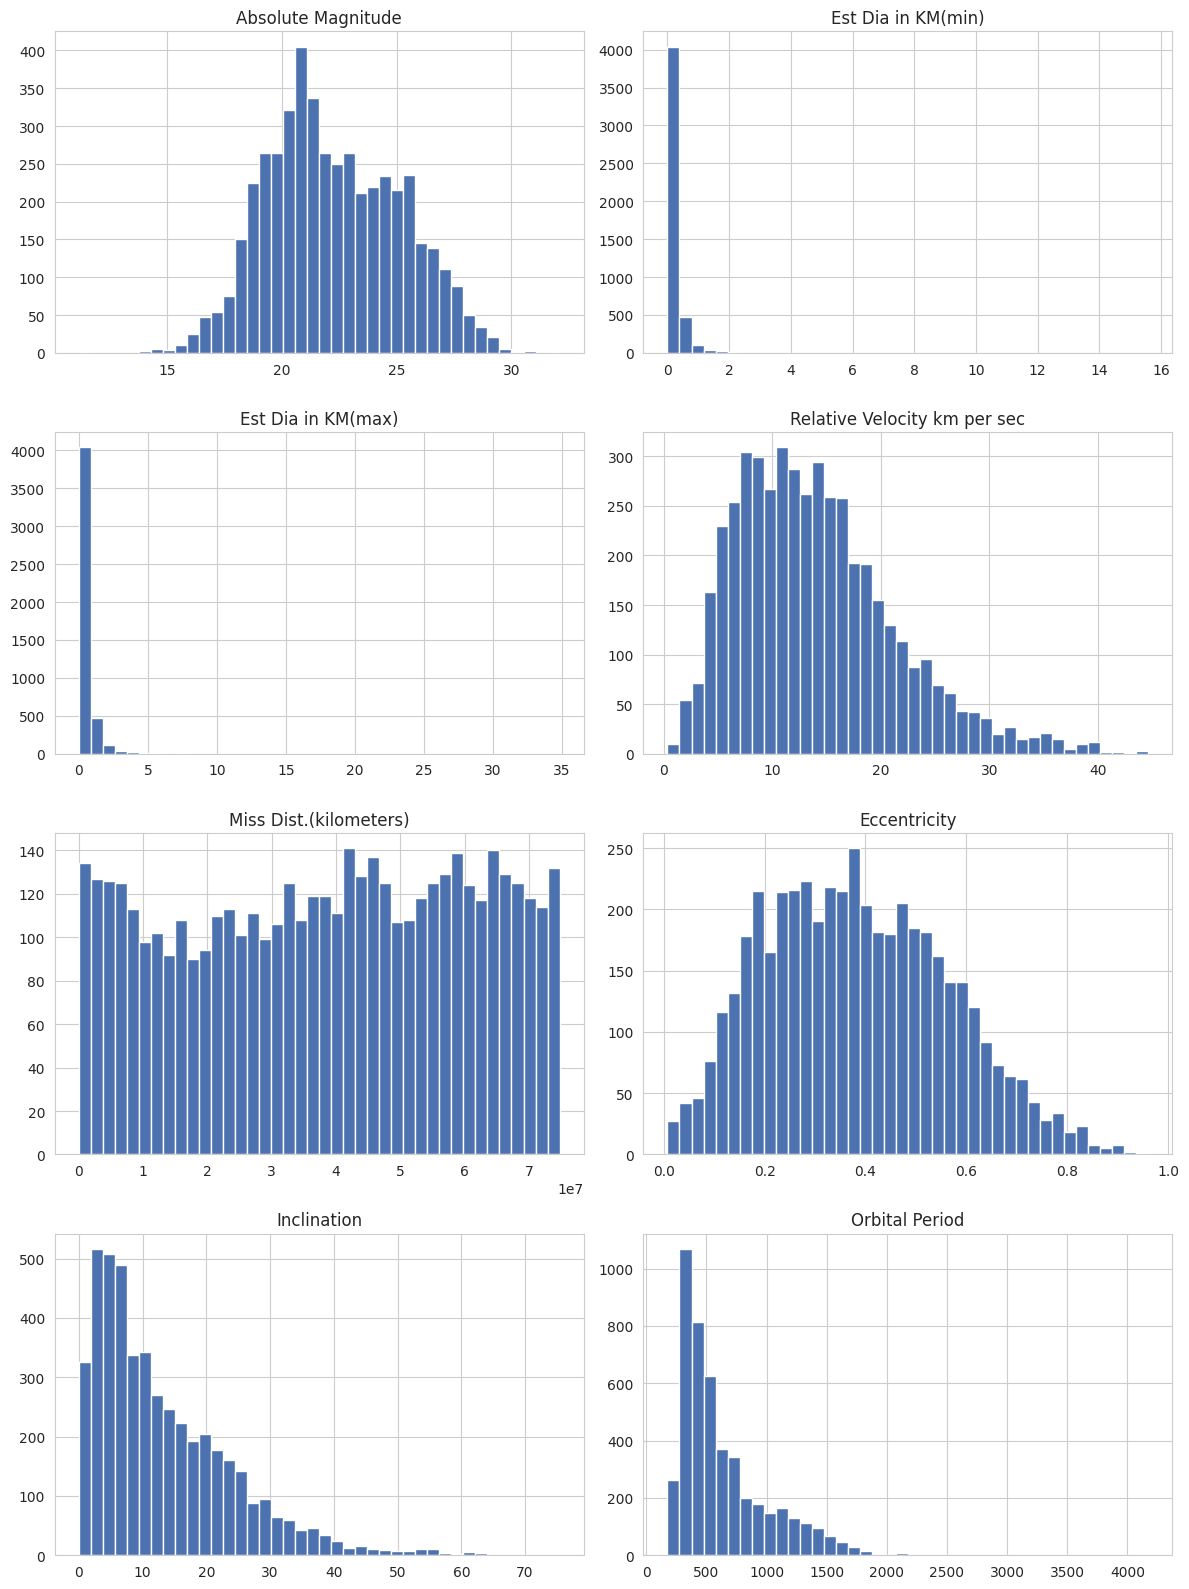

In [7]:
features = ['Absolute Magnitude', 'Est Dia in KM(min)', 'Est Dia in KM(max)',
            'Relative Velocity km per sec', 'Miss Dist.(kilometers)',
            'Eccentricity', 'Inclination', 'Orbital Period']

fig, axes = plt.subplots(4, 2, figsize=(12, 16))
axes = axes.flatten()

for i, feat in enumerate(features):
    axes[i].hist(df[feat], bins=40, color='#4C72B0', edgecolor='white')
    axes[i].set_title(feat)

plt.tight_layout()
plt.show()

A few things stand out here:

- Absolute Magnitude looks roughly bell shaped, which makes sense since it's already a log-based brightness scale.
- Diameter, velocity, miss distance, and orbital period are all heavily right skewed, most asteroids are small, slow (relatively), and orbit somewhat close, with a long tail of bigger/faster/further out ones. This is pretty typical for physical measurement data like this and I'll probably want to log-transform some of these before modeling.
- Eccentricity is mostly clustered under 0.5, meaning most of these orbits aren't wildly stretched out.
- Inclination has a big spike near 0 with a long tail out past 30 degrees.

Nothing here looks like a data entry error, the skew is just the nature of asteroid measurements.

## How These Features Relate to the Hazardous Label

This is the part that actually matters for the classification problem. If hazardous and non-hazardous asteroids don't look different on these features, this is going to be a genuinely hard prediction problem.

/sessions/inspiring-gallant-cannon/tmp/ipykernel_8/3968239106.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Hazardous', y=feat, ax=ax, palette=['#4C72B0', '#C44E52'])
/sessions/inspiring-gallant-cannon/tmp/ipykernel_8/3968239106.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Hazardous', y=feat, ax=ax, palette=['#4C72B0', '#C44E52'])
/sessions/inspiring-gallant-cannon/tmp/ipykernel_8/3968239106.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Hazardous', y=feat, ax=ax, palette=['#4C72B0', '

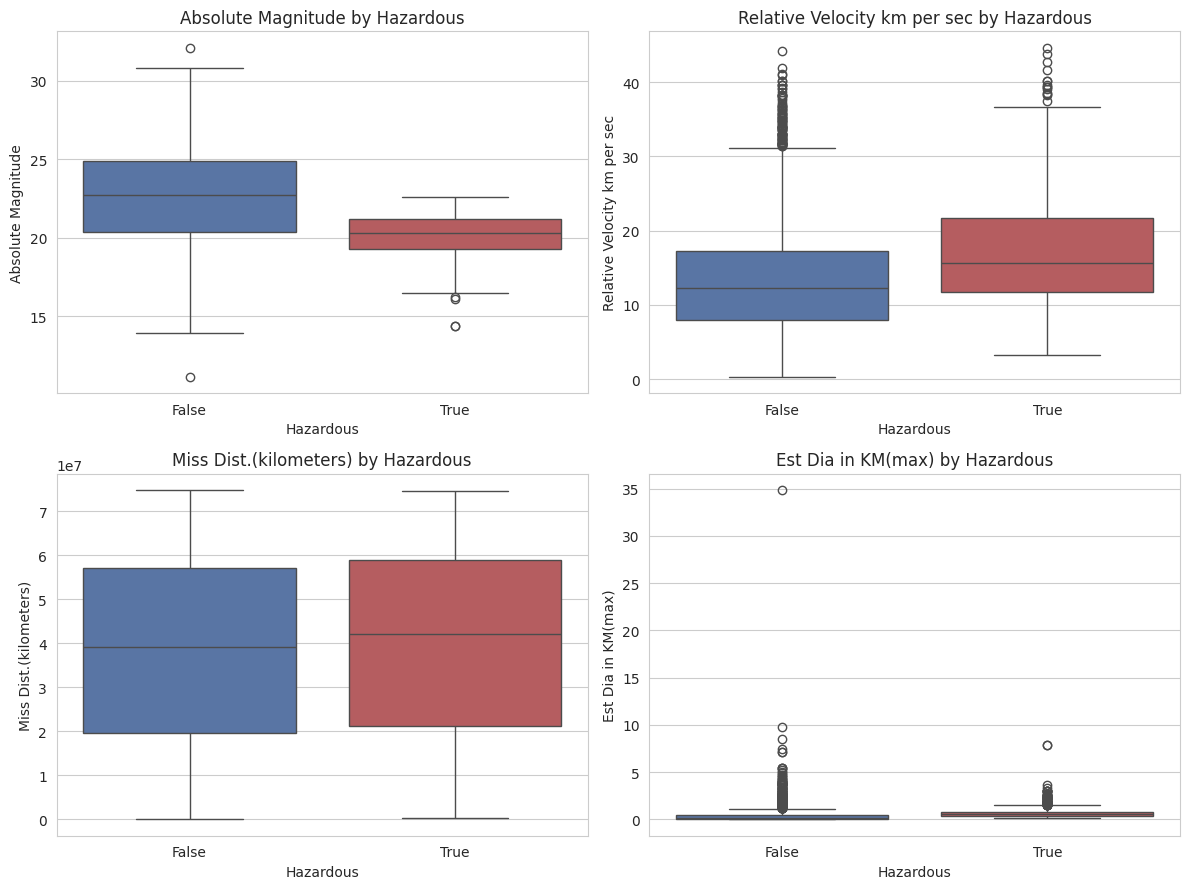

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))

pairs = [
    ('Absolute Magnitude', axes[0,0]),
    ('Relative Velocity km per sec', axes[0,1]),
    ('Miss Dist.(kilometers)', axes[1,0]),
    ('Est Dia in KM(max)', axes[1,1]),
]

for feat, ax in pairs:
    sns.boxplot(data=df, x='Hazardous', y=feat, ax=ax, palette=['#4C72B0', '#C44E52'])
    ax.set_title(f'{feat} by Hazardous')

plt.tight_layout()
plt.show()

This is a good sign. Hazardous asteroids clearly skew toward lower absolute magnitude (meaning bigger objects, since magnitude is inverted), larger diameter, and higher relative velocity. Miss distance is noisier but there's still some separation. Basically NASA's hazardous label appears to be tracking size and speed pretty directly, which honestly makes sense given the proposal itself said the label comes from a size-and-distance threshold rule rather than a purely physical danger assessment. That's actually useful context, it means the model isn't predicting "real danger" so much as predicting NASA's rule, which is worth calling out again in the final writeup so nobody walks away thinking this is a physics simulation.

In [9]:
num_df = df.select_dtypes(include=[np.number]).copy()
num_df['Hazardous'] = df['Hazardous'].astype(int)

corr = num_df.corr()['Hazardous'].drop('Hazardous').sort_values(key=abs, ascending=False)
corr.head(15)

Orbit Uncertainity             -0.328721
Absolute Magnitude             -0.325522
Minimum Orbit Intersection     -0.288949
Neo Reference ID               -0.269028
Name                           -0.269028
Orbit ID                        0.247369
Perihelion Distance            -0.207027
Relative Velocity km per sec    0.191970
Miles per hour                  0.191970
Relative Velocity km per hr     0.191970
Eccentricity                    0.183269
Est Dia in Miles(max)           0.132424
Est Dia in M(min)               0.132424
Est Dia in Feet(max)            0.132424
Est Dia in Feet(min)            0.132424
Name: Hazardous, dtype: float64

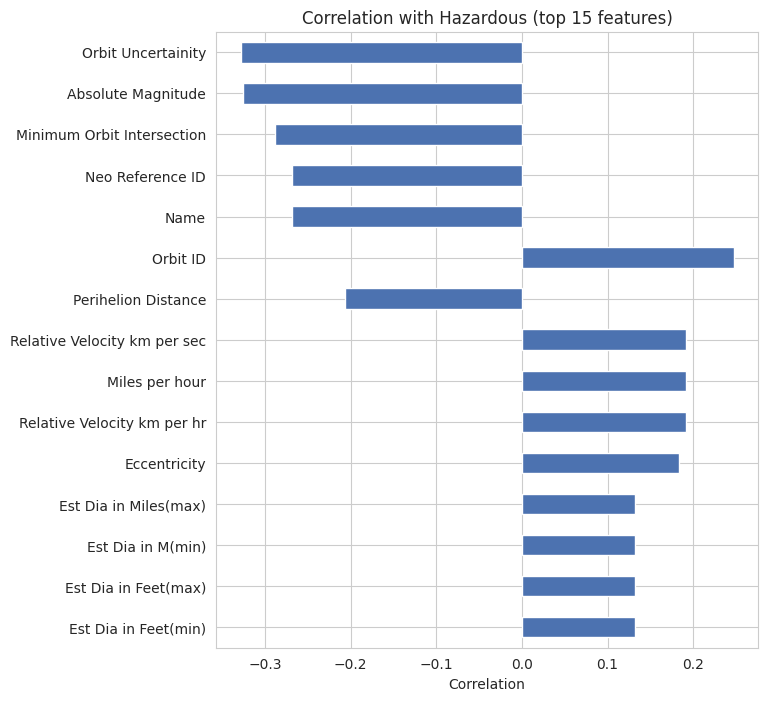

In [10]:
plt.figure(figsize=(7, 8))
corr.head(15).plot(kind='barh', color='#4C72B0')
plt.gca().invert_yaxis()
plt.title('Correlation with Hazardous (top 15 features)')
plt.xlabel('Correlation')
plt.show()

Absolute Magnitude has by far the strongest correlation with the target (negative, since smaller magnitude number means bigger asteroid), followed by the diameter columns, which is expected since they're basically derived from magnitude anyway. Minimum Orbit Intersection and Miss Distance also show up, which tracks with the "how close it gets to Earth" part of the problem definition. A lot of the diameter columns are redundant with each other (km/miles/feet versions of the same measurement) so I won't need all of them going into modeling, just one consistent unit.

## Progress Report

I've loaded the full NASA NEO dataset (4687 rows, 40 columns) that Cohen linked in the proposal and confirmed it matches what was described, no missing values, and a real "Hazardous" target column already present with about 755 hazardous cases versus 3932 non-hazardous. That's roughly a 16/84 split, so class imbalance is something I'll need to handle carefully once I start modeling rather than just eyeballing accuracy.

**Direction:** This is a supervised classification problem. The proposal is explicit that thousands of past asteroids already carry NASA's hazardous/not-hazardous label, and the actual client question is whether the same measurements taken on a newly found asteroid can predict that same label before a human reviews it. There's no ambiguity here about supervised versus unsupervised, the target already exists in the data, so I'm not treating this as a clustering or pattern-discovery problem. My EDA backs this up too, since the features that Cohen called out in the proposal (size, speed, closeness) actually do separate hazardous from non-hazardous asteroids in the boxplots above, especially Absolute Magnitude and the diameter columns, so there's real predictive signal to work with rather than noise.

**What I found in the EDA:** the dataset is clean in the sense that there's nothing missing, but there's a lot of redundancy across the 40 columns, several are just unit conversions of the same measurement (diameter in km, miles, and feet, or velocity in km/sec vs km/hr vs mph), and two columns (Orbiting Body, Equinox) are constants that don't vary at all across the dataset, so those were dropped. The physical features are all right-skewed, which is normal for this kind of astronomical data but means I'll probably log-transform a few of them before feeding anything into a model. The correlation check confirms Absolute Magnitude is the single strongest signal for the Hazardous label, which fits with NASA's own classification approach since size is one of the two main criteria they use for the hazardous designation in the first place.

**One thing worth flagging for Cohen:** the proposal's constraint section already notes that "Hazardous" reflects NASA's size-and-distance threshold rule rather than a direct physical danger measurement. My EDA reinforces this since the label tracks size and speed cleanly enough. I'll make sure this distinction is clear in the final writeup so the stakeholder understands the model predicts NASA's classification rule, not "real" risk in some deeper sense.

**Next steps toward Checkpoint 2:** trim down the redundant columns, decide on transformations for the skewed features, set up a stratified train/test split given the imbalance, and start building and comparing a couple of classification models (probably logistic regression as a baseline and something like random forest or gradient boosting after that), then evaluate with precision, recall, F1, and ROC-AUC rather than raw accuracy, tied back to the stakeholder's actual use case of a ranked, explainable shortlist for weekly telescope scheduling.